# Titanic - EDA

## 1. First look at the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')

print(f"Train: {train.shape}, Test: {test.shape}")
train.head()

Train: (891, 12), Test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Target

Text(0.5, 1.0, 'Target distribution')

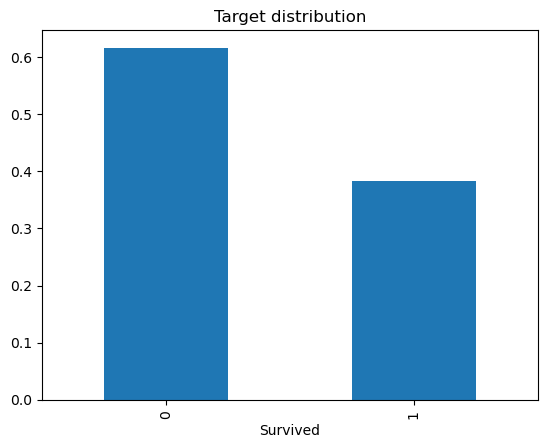

In [2]:
train['Survived'].value_counts(normalize=True).plot(kind='bar')
plt.title('Target distribution')

~38% of survivors. Quite balanced, so 'accuracy' will be our metric.

## 3. Missing Values

In [3]:
missing = pd.concat([train, test]).isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)

Cabin       0.774637
Survived    0.319328
Age         0.200917
Embarked    0.001528
Fare        0.000764
dtype: float64


## 4. Numeric features

Text(0.5, 1.0, 'Survival rate by Age')

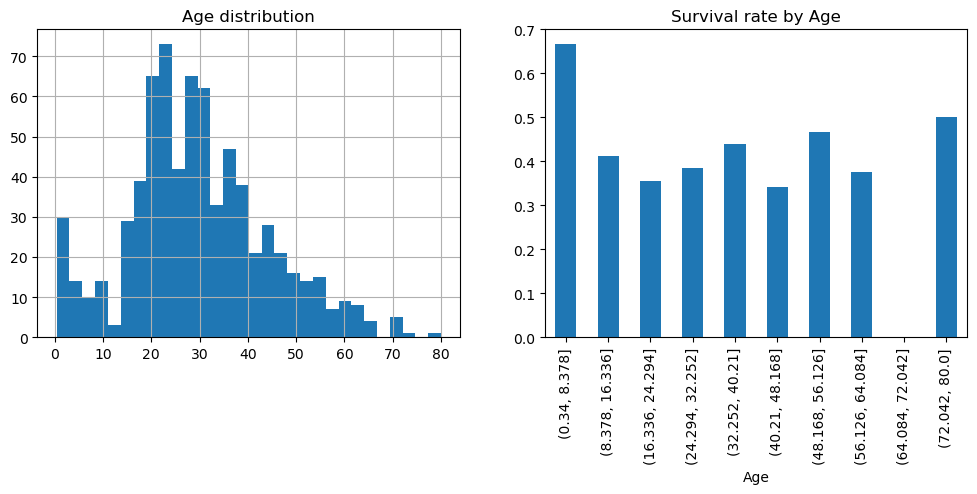

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['Age'].hist(bins=30, ax=axes[0])
axes[0].set_title('Age distribution')

train.groupby(pd.cut(train['Age'], bins=10))['Survived'].mean().plot(
    kind='bar', ax=axes[1]
)
axes[1].set_title('Survival rate by Age')

More children (age < 10) survived than older people.

## 5. Categorical features

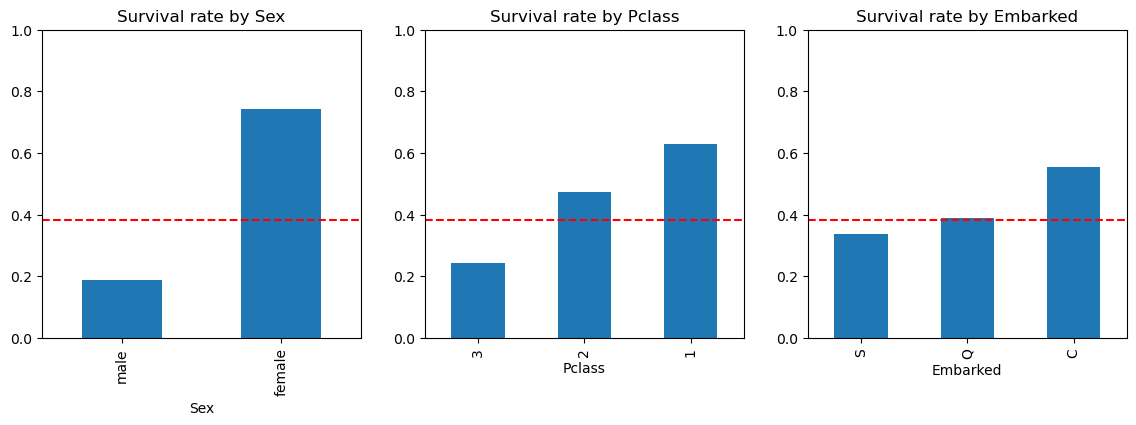

In [5]:
cat_features = ['Sex', 'Pclass', 'Embarked']

fig, axes = plt.subplots(1, len(cat_features), figsize=(14, 4))
for ax, feat in zip(axes, cat_features):
    train.groupby(feat)['Survived'].mean().sort_values().plot(kind='bar', ax=ax)
    ax.set_title(f'Survival rate by {feat}')
    ax.set_ylim(0, 1)
    ax.axhline(train['Survived'].mean(), color='red', linestyle='--', label='Overall')

1. Most of the survivors were women (~75%).
2. Higher Class - higher chance of surviving.
3. Passengers who embarked at Cherbourg had the highest survival rate.

## 6. Correlations

<Axes: >

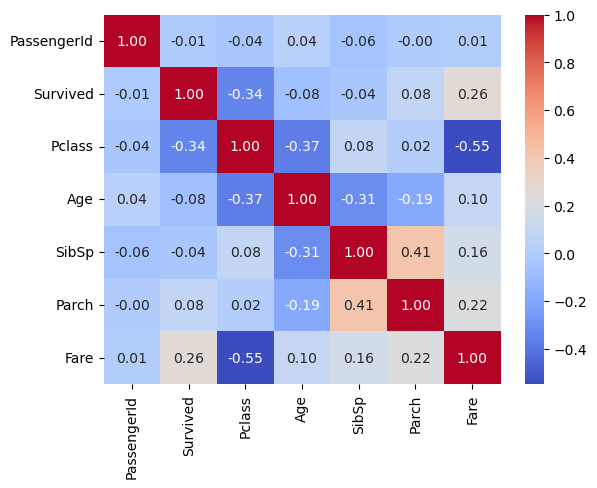

In [6]:
corr = train.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

No strong multicollinearity between features.
Fare and Pclass correlate moderately (−0.55) — expected,
as higher class tickets cost more.

## Final thoughts

**Strong features**
 - Sex: women survived ~3 times more frequently than men
 - Pclass: determined gradient 1 > 2 > 3
 - Title (potentially): need to extract it from Name

**Missing Values**
 - Age (20%): fill with Pclass x Sex median, not global
 - Cabin (77%): create binary feature has_cabin, drop other rows

**Potential new features**
 - FamilySize = SibSp + Parch + 1
 - Title from Name
 - IsAlone